# Importing the cifar dataset from Kaggle

In [15]:
# Make a directory for Kaggle and move the kaggle.json file there
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/

# Set permissions (this is important for security)
!chmod 600 ~/.kaggle/kaggle.json

In [16]:
!ls

sample_data


In [17]:
!kaggle competitions download -c cifar-10

100% 715M/715M [00:09<00:00, 82.4MB/s]



In [18]:
!unzip cifar-10.zip -d cifar-10

Archive:  cifar-10.zip
  inflating: cifar-10/sampleSubmission.csv  
  inflating: cifar-10/test.7z        
  inflating: cifar-10/train.7z       
  inflating: cifar-10/trainLabels.csv  


In [19]:
!pip install py7zr

In [20]:
import py7zr

archive = py7zr.SevenZipFile('/content/cifar-10/train.7z', mode='r')
archive.extractall() #archive.extractall(path='')
archive.close()


# Importing the dependencies

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from sklearn.model_selection import train_test_split


In [22]:
filenames = os.listdir('train')
len(filenames)


50000

In [23]:
print(filenames[0:5])
print(filenames[-5:])

['26941.png', '20652.png', '30205.png', '47176.png', '37935.png']
['41783.png', '5213.png', '29556.png', '27180.png', '49383.png']


# Labels Processing

In [24]:
labels_df = pd.read_csv('/content/cifar-10/trainLabels.csv')


In [25]:
labels_df.shape

(50000, 2)

In [26]:
labels_df.head()

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


In [27]:
labels_df['label'].value_counts()

,count
label,
frog,5000
truck,5000
deer,5000
automobile,5000
bird,5000
horse,5000
ship,5000
cat,5000
dog,5000


In [28]:
labels_dictionary = {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}

labels = [labels_dictionary[i] for i in labels_df['label']]
print(labels)

[6, 9, 9, 4, 1, 1, 2, 7, 8, 3, 4, 7, 7, 2, 9, 9, 9, 3, 2, 6, 4, 3, 6, 6, 2, 6, 3, 5, 4, 0, 0, 9, 1, 3, 4, 0, 3, 7, 3, 3, 5, 2, 2, 7, 1, 1, 1, 2, 2, 0, 9, 5, 7, 9, 2, 2, 5, 2, 4, 3, 1, 1, 8, 2, 1, 1, 4, 9, 7, 8, 5, 9, 6, 7, 3, 1, 9, 0, 3, 1, 3, 5, 4, 5, 7, 7, 4, 7, 9, 4, 2, 3, 8, 0, 1, 6, 1, 1, 4, 1, 8, 3, 9, 6, 6, 1, 8, 5, 2, 9, 9, 8, 1, 7, 7, 0, 0, 6, 9, 1, 2, 2, 9, 2, 6, 6, 1, 9, 5, 0, 4, 7, 6, 7, 1, 8, 1, 1, 2, 8, 1, 3, 3, 6, 2, 4, 9, 9, 5, 4, 3, 6, 7, 4, 6, 8, 5, 5, 4, 3, 1, 8, 4, 7, 6, 0, 9, 5, 1, 3, 8, 2, 7, 5, 3, 4, 1, 5, 7, 0, 4, 7, 5, 5, 1, 0, 9, 6, 9, 0, 8, 7, 8, 8, 2, 5, 2, 3, 5, 0, 6, 1, 9, 3, 6, 9, 1, 3, 9, 6, 6, 7, 1, 0, 9, 5, 8, 5, 2, 9, 0, 8, 8, 0, 6, 9, 1, 1, 6, 3, 7, 6, 6, 0, 6, 6, 1, 7, 1, 5, 8, 3, 6, 6, 8, 6, 8, 4, 6, 6, 1, 3, 8, 3, 4, 1, 7, 1, 3, 8, 5, 1, 1, 4, 0, 9, 3, 7, 4, 9, 9, 2, 4, 9, 9, 1, 0, 5, 9, 0, 8, 2, 1, 2, 0, 5, 6, 3, 2, 7, 8, 8, 6, 0, 7, 9, 4, 5, 6, 4, 2, 1, 1, 2, 1, 5, 9, 9, 0, 8, 4, 1, 1, 6, 3, 3, 9, 0, 7, 9, 7, 7, 9, 1, 5, 1, 6, 6, 8, 7, 1, 3, 0, 

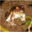

numpy.ndarray

In [29]:
#displaying sample image
import cv2
from google.colab.patches import cv2_imshow

img= cv2.imread('/content/train/1.png')
cv2_imshow(img)
type(img)

In [30]:
id_list = list(labels_df['id'])
id_list[0:5]

[1, 2, 3, 4, 5]

# Image Processing

In [31]:
# convert images to numpy arrays
tarin_data_folder = '/content/train/'

train_data = []

for id in id_list:
  image = cv2.imread(tarin_data_folder + str(id) + '.png')
  train_data.append(image)



In [32]:
type(train_data),len(train_data)

(list, 50000)

In [33]:
train_data[0].shape

(32, 32, 3)

array([[[ 63,  62,  59],
        [ 45,  46,  43],
        [ 43,  48,  50],
        ...,
        [108, 132, 158],
        [102, 125, 152],
        [103, 124, 148]],

       [[ 20,  20,  16],
        [  0,   0,   0],
        [  0,   8,  18],
        ...,
        [ 55,  88, 123],
        [ 50,  83, 119],
        [ 57,  87, 122]],

       [[ 21,  24,  25],
        [  0,   7,  16],
        [  8,  27,  49],
        ...,
        [ 50,  84, 118],
        [ 50,  84, 120],
        [ 42,  73, 109]],

       ...,

       [[ 96, 170, 208],
        [ 34, 153, 201],
        [ 26, 161, 198],
        ...,
        [ 70, 133, 160],
        [  7,  31,  56],
        [ 20,  34,  53]],

       [[ 96, 139, 180],
        [ 42, 123, 173],
        [ 30, 144, 186],
        ...,
        [ 94, 148, 184],
        [ 34,  62,  97],
        [ 34,  53,  83]],

       [[116, 144, 177],
        [ 94, 129, 168],
        [ 87, 142, 179],
        ...,
        [140, 184, 216],
        [ 84, 118, 151],
        [ 72,  92, 123]]], dtype=uint8)
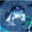

In [34]:
train_data[0]

In [35]:
# convert images and labels to numpy array

X = np.array(train_data)
Y = np.array(labels)

In [36]:
print(X.shape, Y.shape)

(50000, 32, 32, 3) (50000,)


# Train Test Split

In [37]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [38]:
print(X_train.shape,X_test.shape,Y_train.shape,Y_test.shape)

(40000, 32, 32, 3) (10000, 32, 32, 3) (40000,) (10000,)


In [39]:
# Scaling the data

X_train_scaled = X_train/255.0
X_test_scaled = X_test/255.0

# Building the Neural Network

In [40]:
import tensorflow as tf
from tensorflow import keras

In [42]:
num_of_classes = 10

# setting up the layers of neural network
model = keras.Sequential([
                          keras.layers.Flatten(input_shape=(32,32,3)),
                          keras.layers.Dense(64,activation='relu'),
                          keras.layers.Dense(num_of_classes,activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [43]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [44]:
#training the neural network
model.fit(X_train_scaled,Y_train,validation_split=0.1,epochs=10)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2772 - loss: 1.9669 - val_accuracy: 0.3397 - val_loss: 1.8316
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3336 - loss: 1.8495 - val_accuracy: 0.3495 - val_loss: 1.8096
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3573 - loss: 1.7935 - val_accuracy: 0.2965 - val_loss: 1.9027
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3686 - loss: 1.7644 - val_accuracy: 0.3715 - val_loss: 1.7425
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3740 - loss: 1.7417 - val_accuracy: 0.3438 - val_loss: 1.7893
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3807 - loss: 1.7262 - val_accuracy: 0.3870 - val_loss: 1.7080
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3854 - loss: 1.7152 - val_accuracy: 0.3902 - val_loss: 1.7272
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3904 - loss: 1.7018 - 

# Transfer Learning using ResNet50

In [48]:
from tensorflow.keras import Sequential, models, layers
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.models import Model, load_model




In [49]:
convolutional_base = ResNet50(weights='imagenet', include_top=False, input_shape=(32,32,3))
convolutional_base.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [63]:
model = Sequential()
model.add(convolutional_base)
model.add(layers.Flatten())
model.add(layers.BatchNormalization())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.BatchNormalization())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.BatchNormalization())
model.add(layers.Dense(num_of_classes, activation='softmax'))

In [64]:
from tensorflow.keras.optimizers import RMSprop
opt = RMSprop(learning_rate=0.0001)
model.compile(optimizer=opt,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [66]:
history = model.fit(X_train_scaled,Y_train,validation_split=0.1,epochs=10)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 36s 32ms/step - accuracy: 0.5788 - loss: 1.3533 - val_accuracy: 0.7387 - val_loss: 0.8391
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 31s 27ms/step - accuracy: 0.6925 - loss: 1.0662 - val_accuracy: 0.7818 - val_loss: 0.6871
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.7628 - loss: 0.8553 - val_accuracy: 0.7910 - val_loss: 0.6682
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.8104 - loss: 0.7030 - val_accuracy: 0.8065 - val_loss: 0.6211
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 28s 25ms/step - accuracy: 0.8453 - loss: 0.5839 - val_accuracy: 0.8020 - val_loss: 0.6835
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.8821 - loss: 0.4781 - val_accuracy: 0.8092 - val_loss: 0.6555
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.9028 - loss: 0.4025 - val_accuracy: 0.8215 - val_loss: 0.6135
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9211 -

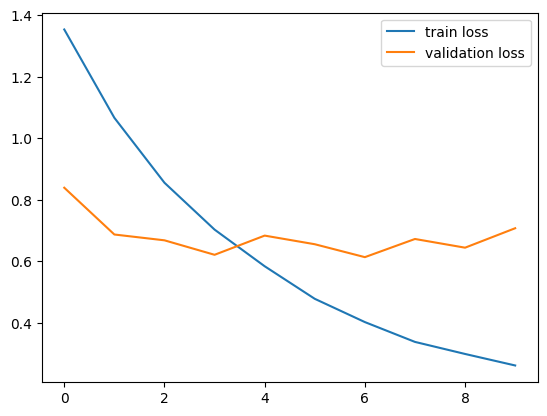

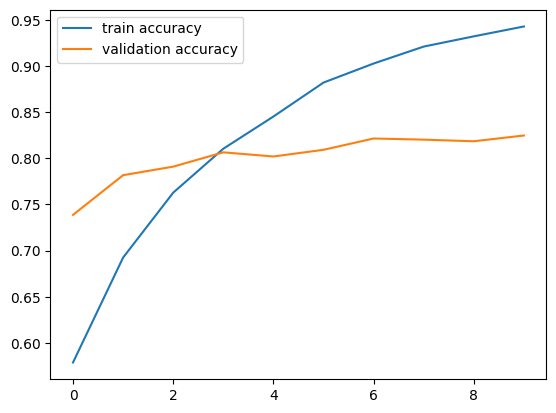

In [67]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['accuracy'], label='train accuracy')
plt.plot(h.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Original Image Label (index): 6 (frog)
Predicted Image Label (index): 6 (frog)


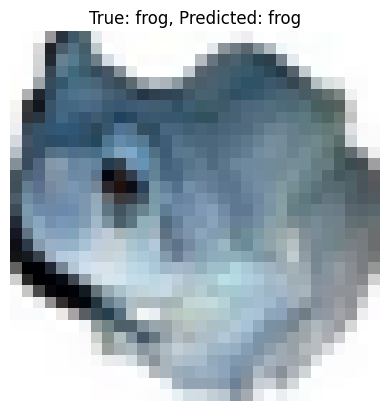

In [70]:
import numpy as np

# Take one image from the test set (e.g., the first one)
# Ensure X_test_scaled and Y_test are available in the environment
single_image = X_test_scaled[5]
single_image_label = Y_test[5]

# Reshape the image to a batch of 1 (model expects a batch dimension)
input_image_reshaped = np.expand_dims(single_image, axis=0)

# Make a prediction
predictions = model.predict(input_image_reshaped)

# Get the predicted class (the one with the highest probability)
predicted_class_index = np.argmax(predictions[0])

# Invert the labels_dictionary to get class names from indices
inverse_labels_dictionary = {v: k for k, v in labels_dictionary.items()}

print(f"Original Image Label (index): {single_image_label} ({inverse_labels_dictionary[single_image_label]})")
print(f"Predicted Image Label (index): {predicted_class_index} ({inverse_labels_dictionary[predicted_class_index]})")

# Optionally, display the image
import matplotlib.pyplot as plt
plt.imshow(single_image)
plt.title(f"True: {inverse_labels_dictionary[single_image_label]}, Predicted: {inverse_labels_dictionary[predicted_class_index]}")
plt.axis('off')
plt.show()